This dataset represents a multi-class Image Classification problem. 
The dataset contains product surface images organized into four 
categories — normal, scratch, dent, and stain. The goal is to train 
a CNN model to correctly classify each image into one of these four 
defect categories. Image classification is appropriate because each 
image requires only a single label, with no need to locate objects 
or segment pixels. This directly maps to real world manufacturing 
quality inspection, where automated systems must quickly identify 
defective products on a production line.

In [1]:
import os

# Check your dataset path
dataset_path = r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

# List all folders (classes)
classes = os.listdir(dataset_path)
print("Classes found:", classes)

Classes found: ['.DS_Store', 'dent', 'normal', 'scratch', 'stain']


Number of Classes: 4
Class Names: ['dent', 'normal', 'scratch', 'stain']

Number of Images Per Class:
  dent       : 120 images
  normal     : 120 images
  scratch    : 120 images
  stain      : 120 images

  Total Images : 480

Image Dimensions (first image from each class):
  dent       : (96, 96) (Width x Height) | Mode: RGB
  normal     : (96, 96) (Width x Height) | Mode: RGB
  scratch    : (96, 96) (Width x Height) | Mode: RGB
  stain      : (96, 96) (Width x Height) | Mode: RGB

Sample Images From Each Class:


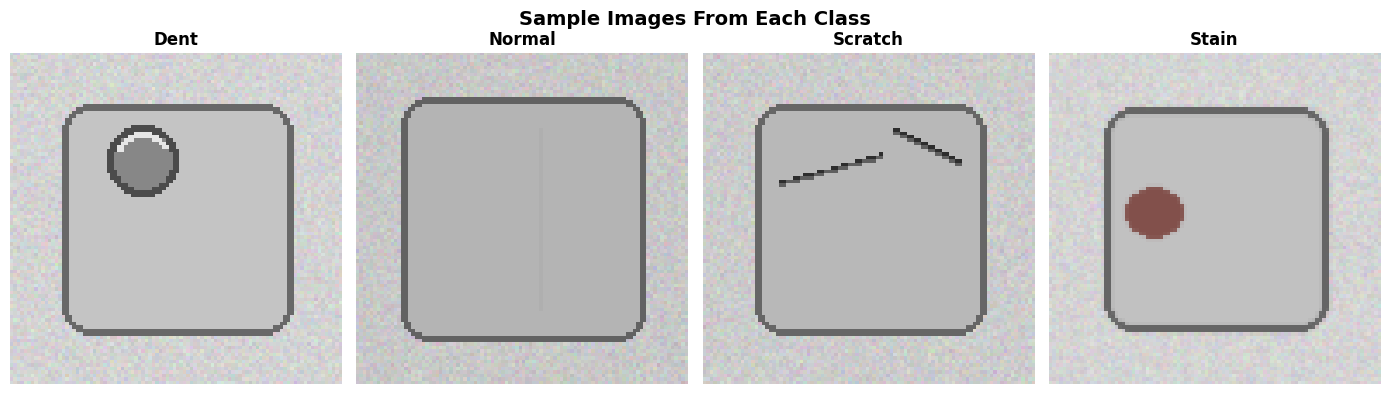


Class Imbalance Check:
  dent       : 120 images (25.00%)
  normal     : 120 images (25.00%)
  scratch    : 120 images (25.00%)
  stain      : 120 images (25.00%)


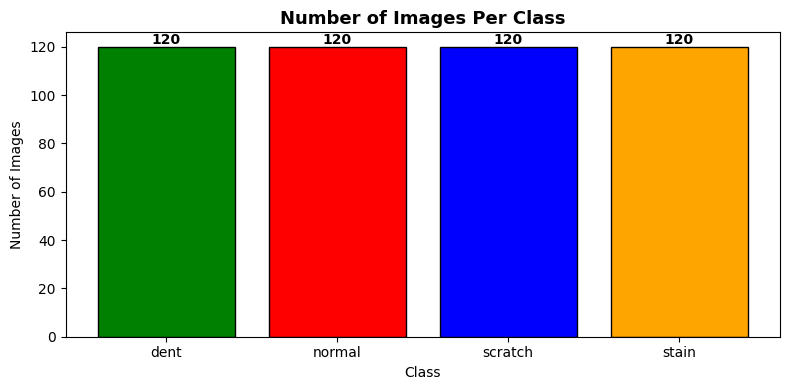


SUMMARY
  Total Classes  : 4
  Total Images   : 480
  Classes        : ['dent', 'normal', 'scratch', 'stain']
  Imbalance      : No imbalance — all classes have equal images


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Dataset Path 
dataset_path = r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

# Step 1: Number of Classes 
# Remove .DS_Store (it is a hidden Mac file, not a class)
classes = [c for c in os.listdir(dataset_path) if c != '.DS_Store']
print("=" * 50)
print("Number of Classes:", len(classes))
print("Class Names:", classes)

# Step 2: Number of Images Per Class 
print("\n" + "=" * 50)
print("Number of Images Per Class:")
print("=" * 50)

image_counts = {}
for cls in classes:
    cls_path  = os.path.join(dataset_path, cls)
    images    = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    image_counts[cls] = len(images)
    print(f"  {cls:<10} : {len(images)} images")

print(f"\n  Total Images : {sum(image_counts.values())}")

# Step 3: Image Dimensions
print("\n" + "=" * 50)
print("Image Dimensions (first image from each class):")
print("=" * 50)

for cls in classes:
    cls_path   = os.path.join(dataset_path, cls)
    first_img  = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.jpeg', '.png'))][0]
    img        = Image.open(os.path.join(cls_path, first_img))
    print(f"  {cls:<10} : {img.size} (Width x Height) | Mode: {img.mode}")

# Step 4: Sample Images From Each Class 
print("\n" + "=" * 50)
print("Sample Images From Each Class:")
print("=" * 50)

fig, axes = plt.subplots(1, len(classes), figsize=(14, 4))
fig.suptitle("Sample Images From Each Class", fontsize=14, fontweight='bold')

for i, cls in enumerate(classes):
    cls_path  = os.path.join(dataset_path, cls)
    first_img = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.jpeg', '.png'))][0]
    img       = Image.open(os.path.join(cls_path, first_img))
    axes[i].imshow(img)
    axes[i].set_title(cls.capitalize(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Step 5: Class Imbalance Check 
print("\n" + "=" * 50)
print("Class Imbalance Check:")
print("=" * 50)

total = sum(image_counts.values())
for cls, count in image_counts.items():
    percentage = (count / total) * 100
    print(f"  {cls:<10} : {count} images ({percentage:.2f}%)")

# Plot class distribution
plt.figure(figsize=(8, 4))
plt.bar(image_counts.keys(), image_counts.values(),
        color=['green', 'red', 'blue', 'orange'], edgecolor='black')
plt.title("Number of Images Per Class", fontsize=13, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Number of Images")
for i, (cls, count) in enumerate(image_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Summary 
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"  Total Classes  : {len(classes)}")
print(f"  Total Images   : {total}")
print(f"  Classes        : {classes}")
max_cls = max(image_counts, key=image_counts.get)
min_cls = min(image_counts, key=image_counts.get)
if image_counts[max_cls] == image_counts[min_cls]:
    print(f"  Imbalance      : No imbalance — all classes have equal images")
else:
    print(f"  Imbalance      : Yes — {max_cls} has most ({image_counts[max_cls]}), {min_cls} has least ({image_counts[min_cls]})")

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

#  Settings 
dataset_path = r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

# Fixed size all images will be resized to
IMG_SIZE = 64  # 64x64 pixels

# Class names (no .DS_Store)
classes = [c for c in os.listdir(dataset_path) if c != '.DS_Store']

#  Step 1: Load, Resize and Normalize Images 
print("Loading images...")

images = []   # stores image pixel values
labels = []   # stores class label numbers

for label, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    for img_file in os.listdir(cls_path):
        if img_file.endswith(('.jpg', '.jpeg', '.png')):

            # Load image
            img = Image.open(os.path.join(cls_path, img_file))

            # Step 1a: Resize image to fixed size (64x64)
            img = img.resize((IMG_SIZE, IMG_SIZE))

            # Step 1b: Convert to RGB (in case some images are grayscale)
            img = img.convert('RGB')

            # Step 1c: Convert to numpy array
            img_array = np.array(img)

            # Step 1d: Normalize pixel values from 0-255 to 0-1
            # This helps the model learn faster
            img_array = img_array / 255.0

            images.append(img_array)
            labels.append(label)

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded : {len(images)}")
print(f"Image shape         : {images[0].shape}  (Height x Width x Channels)")
print(f"Labels              : {set(labels)} → {dict(enumerate(classes))}")

# Step 2: Train / Test Split 
print("\nSplitting into Train and Test sets...")

X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,       # 20% for testing
    random_state=42,     # same split every time
    stratify=labels      # keeps class balance in both sets
)

print(f"Training set : {X_train.shape[0]} images")
print(f"Testing set  : {X_test.shape[0]} images")

#  Step 3: Data Augmentation
# Augmentation creates slightly modified copies of images
# This helps the model learn better and avoid overfitting
print("\nApplying Data Augmentation on Training set...")

def augment_image(img):
    # Randomly flip image horizontally
    if np.random.rand() > 0.5:
        img = np.fliplr(img)

    # Randomly flip image vertically
    if np.random.rand() > 0.5:
        img = np.flipud(img)

    # Randomly adjust brightness
    brightness = np.random.uniform(0.8, 1.2)
    img = np.clip(img * brightness, 0, 1)

    return img

# Apply augmentation to training images only
X_train_aug = np.array([augment_image(img) for img in X_train])

print(f"Augmented Training set : {X_train_aug.shape[0]} images")

# Step 4: Reshape for PyTorch
# PyTorch needs images in format: (samples, channels, height, width)
# Currently they are:            (samples, height, width, channels)
import torch

X_train_t = torch.tensor(X_train_aug, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_t  = torch.tensor(X_test,      dtype=torch.float32).permute(0, 3, 1, 2)
y_train_t = torch.tensor(y_train,     dtype=torch.long)
y_test_t  = torch.tensor(y_test,      dtype=torch.long)

print("\nFinal Shapes for PyTorch:")
print(f"X_train : {X_train_t.shape}  (samples, channels, height, width)")
print(f"X_test  : {X_test_t.shape}")
print(f"y_train : {y_train_t.shape}")
print(f"y_test  : {y_test_t.shape}")

#  Summary 
print("\n" + "=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)
print(f"  Image Size        : {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"  Pixel Values      : Normalized to 0-1")
print(f"  Training Images   : {X_train_t.shape[0]}")
print(f"  Testing  Images   : {X_test_t.shape[0]}")
print(f"  Augmentation      : Flip + Brightness applied to training set")
print(f"  Classes           : {dict(enumerate(classes))}")

Loading images...
